In [1]:
import numpy as np
import matplotlib.pyplot as plt
import structural_modules.Utils as Utils
import structural_modules.TM_solver as TM_solver
import structural_modules.TM_matrixes as TM_matrixes
import structural_modules.TE_solver as TE_solver
import structural_modules.TE_matrixes as TE_matrixes
import pandas as pd
from scipy.interpolate import UnivariateSpline 
from tqdm import tqdm
import time
from matplotlib.colors import LinearSegmentedColormap

<font size = "4"> **Initialize Problem**

Parameters

In [3]:
theta = 0.0 # Angle of incidence in radians
wavelength = np.linspace(2.0, 25.0, 46) # Array of wavelengths (in micrometers)
e=[1,1]
Num_ord = 120 # Highest Fourier order considered in the RCWA expansion
slices = 80 # Number of vertical slices used to discretize the surface profile
N = slices - 1

Surface and refractive index

In [3]:
surface_profile = pd.read_csv("csv/Inconel_gratings/nocoating_x1.csv", sep = r"\s+")

surface_profile["x"] = surface_profile["x"].str.replace(",", ".", regex=False).astype(float) * 1e3
surface_profile["y"] = surface_profile["y"].str.replace(",", ".", regex=False).astype(float)
f_left_end, f_right_end, d, periods, permittivity_matrix = Utils.discretize_rugosity_square_staricase(surface_profile, e_m = 2.0, e_d = 1.0, slices = slices)
# surface_profile.info()

<font size = "4"> **Plot geometry** (if there is one)

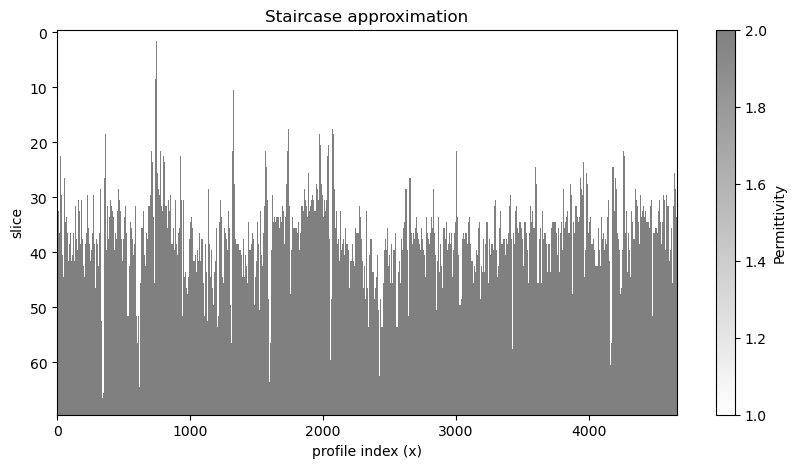

In [4]:
    cmap_white_gray = LinearSegmentedColormap.from_list(
        "white_gray", ["white", "gray"]
    )
    
    plt.figure(figsize=(10, 5))
    plt.imshow(np.real(permittivity_matrix),
               cmap=cmap_white_gray,
               aspect='auto',
               interpolation='nearest')
    plt.colorbar(label='Permittivity')
    plt.title('Staircase approximation')
    plt.xlabel('profile index (x)')
    plt.ylabel('slice')
    plt.show()

In [5]:
resistivities = np.array([1.285, 1.296, 1.306, 1.315, 1.324, 1.333, 1.318])
resistivities = resistivities * 1e-4

def InconelPerm(wavelength, resistivities):
    rho = resistivities[0]  # ohm·m

    n = np.sqrt(0.003 * wavelength / rho)
   

    eps = -2*n**2 + 2j * n**2

    return eps

def InconelPerm2(wavelength, resistivities, index):
    rho = resistivities[index]  # ohm·m

    n = np.sqrt(0.003 * wavelength / rho)
   
    refr = n + 1j * n
    eps = refr ** 2
    return eps
    
InconelPerm2(15.0, resistivities, 6)

682.8528072837632j

# Nocoating x1

Convergence testing

In [15]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================================================
# Convergence analysis for nocoating_x1.csv
# Using only the smallest resistivity case
# ============================================================

# --- Load surface profile ---
surface_profile = pd.read_csv(
    "csv/Inconel_gratings/nocoating_x1.csv",
    sep=r"\s+"
)

surface_profile["x"] = (
    surface_profile["x"]
    .str.replace(",", ".", regex=False)
    .astype(float) * 1e3
)

surface_profile["y"] = (
    surface_profile["y"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# --- Resistivity values ---
temperatures = np.arange(200, 801, 100)

resistivities = np.array([1.285, 1.296, 1.306, 1.315, 1.324, 1.333, 1.318])
resistivities = resistivities * 1e-4

# Use only the smallest resistivity
idx_min_rho = np.argmin(resistivities)
rho_selected = resistivities[idx_min_rho]
temp_selected = temperatures[idx_min_rho]

print(f"Selected temperature: {temp_selected} ºC")
print(f"Selected resistivity: {rho_selected:.4e}")

# ============================================================
# Convergence grid
# ============================================================

Num_ord_values = [60, 80, 100, 120, 140, 160]
slices_values = [20, 40, 60, 80, 100]

convergence_results = []

# Optional: use all wavelengths
wavelength_conv = wavelength

# If it is too slow, use a reduced wavelength grid:
# wavelength_conv = wavelength[::5]

# ============================================================
# Run convergence analysis
# ============================================================

for slices_conv in slices_values:
    for Num_ord_conv in Num_ord_values:
        if Num_ord_conv <= slices_conv:
            continue
        R_TM = []
        T_TM = []
        A_TM = []
        N = slices_conv - 1
        for wv in tqdm(
            wavelength_conv,
            desc=f"slices={slices_conv}, Num_ord={Num_ord_conv}"
        ):

            # Complex permittivity for selected resistivity
            refractive_index = InconelPerm2(
                wv,
                resistivities,
                idx_min_rho
            )

            # Material arrays
            e_m = np.full(N, refractive_index)
            e_d = np.full(N, 1.0)
            e = [1, refractive_index]

            # Staircase discretization
            f_left_end, f_right_end, d, periods, permittivity_matrix = (
                Utils.discretize_rugosity_square_staricase(
                    surface_profile.copy(),
                    e_m=refractive_index,
                    e_d=1.0,
                    slices=slices_conv
                )
            )

            # RCWA calculation
            R_wv, T_wv = TM_solver.TransRefl(
                N=N,
                e_m=e_m,
                e_d=e_d,
                f1=f_left_end,
                f2=f_right_end,
                period=periods,
                d=d,
                e=e,
                wavelength=wv,
                theta=theta,
                Num_ord=Num_ord_conv,
                permittivity_matrix=None
            )

            A_wv = 1 - (R_wv + T_wv)

            R_TM.append(R_wv)
            T_TM.append(T_wv)
            A_TM.append(A_wv)

        convergence_results.append({
            "slices": slices_conv,
            "Num_ord": Num_ord_conv,
            "temperature_C": temp_selected,
            "resistivity": rho_selected,
            "wavelength_um": np.array(wavelength_conv),
            "R_TM": np.array(R_TM),
            "T_TM": np.array(T_TM),
            "A_TM": np.array(A_TM)
        })


# ============================================================
# Convert results into a long-format DataFrame
# ============================================================

rows = []

for result in convergence_results:
    for i, wv in enumerate(result["wavelength_um"]):
        rows.append({
            "slices": result["slices"],
            "Num_ord": result["Num_ord"],
            "temperature_C": result["temperature_C"],
            "resistivity": result["resistivity"],
            "wavelength_um": wv,
            "R_TM": result["R_TM"][i],
            "T_TM": result["T_TM"][i],
            "A_TM": result["A_TM"][i],
        })

df_conv = pd.DataFrame(rows)

df_conv.to_csv(
    "RCWA_convergence_nocoating_x1_min_resistivity.csv",
    index=False
)

df_conv.head()

Selected temperature: 200 ºC
Selected resistivity: 1.2850e-04


slices=100, Num_ord=160: 100%|█████████████████████████████████████████████████████████| 46/46 [16:04<00:00, 20.97s/it]


,slices,Num_ord,temperature_C,resistivity,wavelength_um,R_TM,T_TM,A_TM
0,20,60,200,0.000129,2.000000,0.330870,0.007972,0.661158
1,20,60,200,0.000129,2.511111,0.385737,0.007713,0.606550
2,20,60,200,0.000129,3.022222,0.451232,0.008164,0.540604
3,20,60,200,0.000129,3.533333,0.511978,0.008699,0.479322
4,20,60,200,0.000129,4.044444,0.564532,0.008713,0.426756


Main calculations

In [7]:
import numpy as np
import pandas as pd
from tqdm import tqdm

surface_profile = pd.read_csv("csv/Inconel_gratings/nocoating_x1.csv", sep = r"\s+")

surface_profile["x"] = surface_profile["x"].str.replace(",", ".", regex=False).astype(float) * 1e3
surface_profile["y"] = surface_profile["y"].str.replace(",", ".", regex=False).astype(float)

# Resistividades correspondientes a T = 200, 300, ..., 800 ºC
temperatures = np.arange(200, 801, 100)

resistivities = np.array([1.285, 1.296, 1.306, 1.315, 1.324, 1.333, 1.318])


resistivities = resistivities * 1e-4   


results = []

for idx, temp in enumerate(temperatures):

    R_TM = []
    T_TM = []
    A_TM = []

    for wv in tqdm(wavelength, desc=f"Temperature {temp} ºC"):

        # Complex permittivity for this wavelength and temperature
        refractive_index = InconelPerm2(wv, resistivities, idx)

        # Assign metal and dielectric permittivity to all layers
        e_m = np.full(N, refractive_index)
        e_d = np.full(N, 1.0)
        e = [1, refractive_index]

        # Discretize the arbitrary surface profile into staircase layers
        f_left_end, f_right_end, d, periods, permittivity_matrix = Utils.discretize_rugosity_square_staricase(
            surface_profile,
            e_m=refractive_index,
            e_d=1.0,
            slices=slices
        )

        # Compute reflection and transmission using RCWA
        R_wv, T_wv = TM_solver.TransRefl(
            N=N,
            e_m=e_m,
            e_d=e_d,
            f1=f_left_end,
            f2=f_right_end,
            period=periods,
            d=d,
            e=e,
            wavelength=wv,
            theta=theta,
            Num_ord=Num_ord,
            permittivity_matrix=None
        )

        # Absorptance / emissivity
        A_wv = 1 - (R_wv + T_wv)

        R_TM.append(R_wv)
        T_TM.append(T_wv)
        A_TM.append(A_wv)

        results.append({
            "temperature_C": temp,
            "resistivity": resistivities[idx],
            "wavelength_um": wv,
            "epsilon_real": np.real(refractive_index),
            "epsilon_imag": np.imag(refractive_index),
            "R_TM": R_wv,
            "T_TM": T_wv,
            "A_TM": A_wv
        })


# Convert to DataFrame
df_results = pd.DataFrame(results)

# Save CSV
df_results.to_csv("RCWA_Inconel_HagenRubens_temperaturesx1.csv", index=False)

df_results.head()

Temperature 800 ºC: 100%|██████████████████████████████████████████████████████████████| 46/46 [07:12<00:00,  9.40s/it]


,temperature_C,resistivity,wavelength_um,epsilon_real,epsilon_imag,R_TM,T_TM,A_TM
0,200,0.000129,2.000000,0.0,93.385214,0.456957,0.002277,0.540767
1,200,0.000129,2.511111,0.0,117.250324,0.530090,0.002018,0.467891
2,200,0.000129,3.022222,0.0,141.115435,0.583282,0.001850,0.414868
3,200,0.000129,3.533333,0.0,164.980545,0.624869,0.001831,0.373300
4,200,0.000129,4.044444,0.0,188.845655,0.658304,0.001888,0.339807


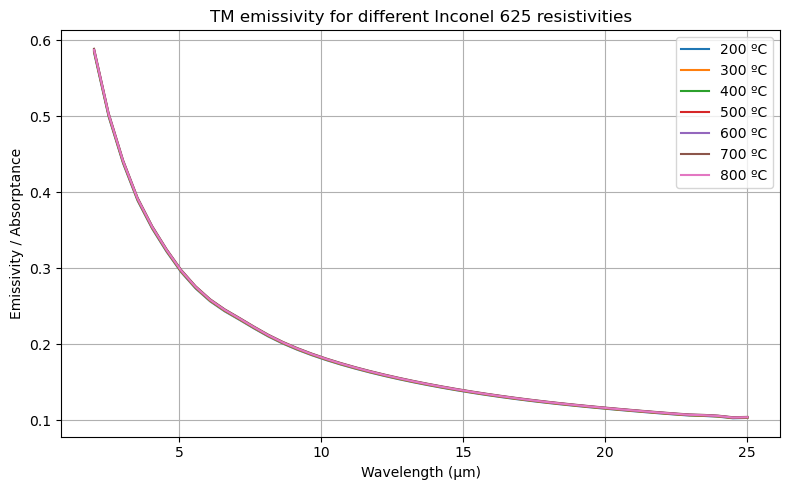

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for temp in temperatures:
    df_temp = df_results[df_results["temperature_C"] == temp]
    plt.plot(
        df_temp["wavelength_um"],
        df_temp["A_TM"],
        label=f"{temp} ºC"
    )

plt.xlabel("Wavelength (µm)")
plt.ylabel("Emissivity / Absorptance")
plt.title("TM emissivity for different Inconel 625 resistivities")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Nocoating x2

In [ ]:
convergence analysis

In [17]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================================================
# Convergence analysis for nocoating_x1.csv
# Using only the smallest resistivity case
# ============================================================

# --- Load surface profile ---
surface_profile = pd.read_csv(
    "csv/Inconel_gratings/nocoating_x2.csv",
    sep=r"\s+"
)

surface_profile["x"] = (
    surface_profile["x"]
    .str.replace(",", ".", regex=False)
    .astype(float) * 1e3
)

surface_profile["y"] = (
    surface_profile["y"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# --- Resistivity values ---
temperatures = np.arange(200, 801, 100)

resistivities = np.array([1.285, 1.296, 1.306, 1.315, 1.324, 1.333, 1.318])
resistivities = resistivities * 1e-4

# Use only the smallest resistivity
idx_min_rho = np.argmin(resistivities)
rho_selected = resistivities[idx_min_rho]
temp_selected = temperatures[idx_min_rho]

print(f"Selected temperature: {temp_selected} ºC")
print(f"Selected resistivity: {rho_selected:.4e}")

# ============================================================
# Convergence grid
# ============================================================

Num_ord_values = [60, 80, 100, 120, 140, 160]
slices_values = [20, 40, 60, 80, 100]

convergence_results = []

# Optional: use all wavelengths
wavelength_conv = wavelength

# If it is too slow, use a reduced wavelength grid:
# wavelength_conv = wavelength[::5]

# ============================================================
# Run convergence analysis
# ============================================================

for slices_conv in slices_values:
    for Num_ord_conv in Num_ord_values:
        if Num_ord_conv <= slices_conv:
                    continue
        R_TM = []
        T_TM = []
        A_TM = []
        N = slices_conv - 1
        for wv in tqdm(
            wavelength_conv,
            desc=f"slices={slices_conv}, Num_ord={Num_ord_conv}"
        ):

            # Complex permittivity for selected resistivity
            refractive_index = InconelPerm2(
                wv,
                resistivities,
                idx_min_rho
            )

            # Material arrays
            e_m = np.full(N, refractive_index)
            e_d = np.full(N, 1.0)
            e = [1, refractive_index]

            # Staircase discretization
            f_left_end, f_right_end, d, periods, permittivity_matrix = (
                Utils.discretize_rugosity_square_staricase(
                    surface_profile.copy(),
                    e_m=refractive_index,
                    e_d=1.0,
                    slices=slices_conv
                )
            )

            # RCWA calculation
            R_wv, T_wv = TM_solver.TransRefl(
                N=N,
                e_m=e_m,
                e_d=e_d,
                f1=f_left_end,
                f2=f_right_end,
                period=periods,
                d=d,
                e=e,
                wavelength=wv,
                theta=theta,
                Num_ord=Num_ord_conv,
                permittivity_matrix=None
            )

            A_wv = 1 - (R_wv + T_wv)

            R_TM.append(R_wv)
            T_TM.append(T_wv)
            A_TM.append(A_wv)

        convergence_results.append({
            "slices": slices_conv,
            "Num_ord": Num_ord_conv,
            "temperature_C": temp_selected,
            "resistivity": rho_selected,
            "wavelength_um": np.array(wavelength_conv),
            "R_TM": np.array(R_TM),
            "T_TM": np.array(T_TM),
            "A_TM": np.array(A_TM)
        })


# ============================================================
# Convert results into a long-format DataFrame
# ============================================================

rows = []

for result in convergence_results:
    for i, wv in enumerate(result["wavelength_um"]):
        rows.append({
            "slices": result["slices"],
            "Num_ord": result["Num_ord"],
            "temperature_C": result["temperature_C"],
            "resistivity": result["resistivity"],
            "wavelength_um": wv,
            "R_TM": result["R_TM"][i],
            "T_TM": result["T_TM"][i],
            "A_TM": result["A_TM"][i],
        })

df_conv = pd.DataFrame(rows)

df_conv.to_csv(
    "RCWA_convergence_nocoating_x2_min_resistivity.csv",
    index=False
)

df_conv.head()

Selected temperature: 200 ºC
Selected resistivity: 1.2850e-04


slices=100, Num_ord=160: 100%|█████████████████████████████████████████████████████████| 46/46 [16:02<00:00, 20.93s/it]


,slices,Num_ord,temperature_C,resistivity,wavelength_um,R_TM,T_TM,A_TM
0,20,60,200,0.000129,2.000000,0.346639,0.018025,0.635336
1,20,60,200,0.000129,2.511111,0.425315,0.018492,0.556194
2,20,60,200,0.000129,3.022222,0.502117,0.016382,0.481502
3,20,60,200,0.000129,3.533333,0.559704,0.014840,0.425456
4,20,60,200,0.000129,4.044444,0.600303,0.014953,0.384744


Main calculations

In [8]:
import numpy as np
import pandas as pd
from tqdm import tqdm

surface_profile = pd.read_csv("csv/Inconel_gratings/nocoating_x2.csv", sep = r"\s+")

surface_profile["x"] = surface_profile["x"].str.replace(",", ".", regex=False).astype(float) * 1e3
surface_profile["y"] = surface_profile["y"].str.replace(",", ".", regex=False).astype(float)

# Resistividades correspondientes a T = 200, 300, ..., 800 ºC
temperatures = np.arange(200, 801, 100)

resistivities = np.array([1.285, 1.296, 1.306, 1.315, 1.324, 1.333, 1.318])
resistivities = resistivities * 1e-4   


results = []

for idx, temp in enumerate(temperatures):

    R_TM = []
    T_TM = []
    A_TM = []

    for wv in tqdm(wavelength, desc=f"Temperature {temp} ºC"):

        # Complex permittivity for this wavelength and temperature
        refractive_index = InconelPerm2(wv, resistivities, idx)

        # Assign metal and dielectric permittivity to all layers
        e_m = np.full(N, refractive_index)
        e_d = np.full(N, 1.0)
        e = [1, refractive_index]

        # Discretize the arbitrary surface profile into staircase layers
        f_left_end, f_right_end, d, periods, permittivity_matrix = Utils.discretize_rugosity_square_staricase(
            surface_profile,
            e_m=refractive_index,
            e_d=1.0,
            slices=slices
        )

        # Compute reflection and transmission using RCWA
        R_wv, T_wv = TM_solver.TransRefl(
            N=N,
            e_m=e_m,
            e_d=e_d,
            f1=f_left_end,
            f2=f_right_end,
            period=periods,
            d=d,
            e=e,
            wavelength=wv,
            theta=theta,
            Num_ord=Num_ord,
            permittivity_matrix=None
        )

        # Absorptance / emissivity
        A_wv = 1 - (R_wv + T_wv)

        R_TM.append(R_wv)
        T_TM.append(T_wv)
        A_TM.append(A_wv)

        results.append({
            "temperature_C": temp,
            "resistivity": resistivities[idx],
            "wavelength_um": wv,
            "epsilon_real": np.real(refractive_index),
            "epsilon_imag": np.imag(refractive_index),
            "R_TM": R_wv,
            "T_TM": T_wv,
            "A_TM": A_wv
        })


# Convert to DataFrame
df_results = pd.DataFrame(results)

# Save CSV
df_results.to_csv("RCWA_Inconel_HagenRubens_temperaturesx2.csv", index=False)

df_results.head()

Temperature 800 ºC: 100%|██████████████████████████████████████████████████████████████| 46/46 [07:24<00:00,  9.67s/it]


,temperature_C,resistivity,wavelength_um,epsilon_real,epsilon_imag,R_TM,T_TM,A_TM
0,200,0.000129,2.000000,0.0,93.385214,0.479714,0.004343,0.515943
1,200,0.000129,2.511111,0.0,117.250324,0.563378,0.004076,0.432546
2,200,0.000129,3.022222,0.0,141.115435,0.620606,0.003944,0.375450
3,200,0.000129,3.533333,0.0,164.980545,0.659614,0.003816,0.336570
4,200,0.000129,4.044444,0.0,188.845655,0.689542,0.003660,0.306797


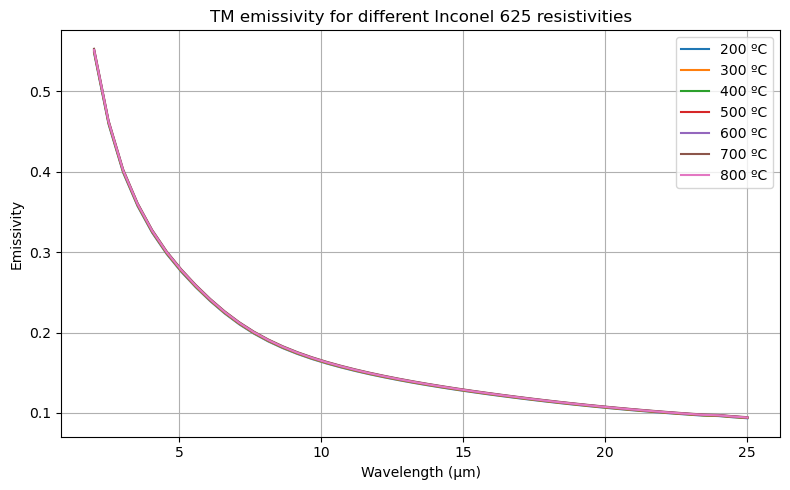

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for temp in temperatures:
    df_temp = df_results[df_results["temperature_C"] == temp]
    plt.plot(
        df_temp["wavelength_um"],
        df_temp["A_TM"],
        label=f"{temp} ºC"
    )

plt.xlabel("Wavelength (µm)")
plt.ylabel("Emissivity")
plt.title("TM emissivity for different Inconel 625 resistivities")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Nocoating y1

convergence analysis

In [19]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================================================
# Convergence analysis for nocoating_x1.csv
# Using only the smallest resistivity case
# ============================================================

# --- Load surface profile ---
surface_profile = pd.read_csv(
    "csv/Inconel_gratings/nocoating_y1.csv",
    sep=r"\s+"
)

surface_profile["x"] = (
    surface_profile["x"]
    .str.replace(",", ".", regex=False)
    .astype(float) * 1e3
)

surface_profile["y"] = (
    surface_profile["y"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# --- Resistivity values ---
temperatures = np.arange(200, 801, 100)

resistivities = np.array([1.285, 1.296, 1.306, 1.315, 1.324, 1.333, 1.318])
resistivities = resistivities * 1e-4

# Use only the smallest resistivity
idx_min_rho = np.argmin(resistivities)
rho_selected = resistivities[idx_min_rho]
temp_selected = temperatures[idx_min_rho]

print(f"Selected temperature: {temp_selected} ºC")
print(f"Selected resistivity: {rho_selected:.4e}")

# ============================================================
# Convergence grid
# ============================================================

Num_ord_values = [60, 80, 100, 120, 140, 160]
slices_values = [20, 40, 60, 80, 100]

convergence_results = []

# Optional: use all wavelengths
wavelength_conv = wavelength

# If it is too slow, use a reduced wavelength grid:
# wavelength_conv = wavelength[::5]

# ============================================================
# Run convergence analysis
# ============================================================

for slices_conv in slices_values:
    for Num_ord_conv in Num_ord_values:
        if Num_ord_conv <= slices_conv:
                    continue
        R_TM = []
        T_TM = []
        A_TM = []
        N = slices_conv - 1
        for wv in tqdm(
            wavelength_conv,
            desc=f"slices={slices_conv}, Num_ord={Num_ord_conv}"
        ):

            # Complex permittivity for selected resistivity
            refractive_index = InconelPerm2(
                wv,
                resistivities,
                idx_min_rho
            )

            # Material arrays
            e_m = np.full(N, refractive_index)
            e_d = np.full(N, 1.0)
            e = [1, refractive_index]

            # Staircase discretization
            f_left_end, f_right_end, d, periods, permittivity_matrix = (
                Utils.discretize_rugosity_square_staricase(
                    surface_profile.copy(),
                    e_m=refractive_index,
                    e_d=1.0,
                    slices=slices_conv
                )
            )

            # RCWA calculation
            R_wv, T_wv = TM_solver.TransRefl(
                N=N,
                e_m=e_m,
                e_d=e_d,
                f1=f_left_end,
                f2=f_right_end,
                period=periods,
                d=d,
                e=e,
                wavelength=wv,
                theta=theta,
                Num_ord=Num_ord_conv,
                permittivity_matrix=None
            )

            A_wv = 1 - (R_wv + T_wv)

            R_TM.append(R_wv)
            T_TM.append(T_wv)
            A_TM.append(A_wv)

        convergence_results.append({
            "slices": slices_conv,
            "Num_ord": Num_ord_conv,
            "temperature_C": temp_selected,
            "resistivity": rho_selected,
            "wavelength_um": np.array(wavelength_conv),
            "R_TM": np.array(R_TM),
            "T_TM": np.array(T_TM),
            "A_TM": np.array(A_TM)
        })


# ============================================================
# Convert results into a long-format DataFrame
# ============================================================

rows = []

for result in convergence_results:
    for i, wv in enumerate(result["wavelength_um"]):
        rows.append({
            "slices": result["slices"],
            "Num_ord": result["Num_ord"],
            "temperature_C": result["temperature_C"],
            "resistivity": result["resistivity"],
            "wavelength_um": wv,
            "R_TM": result["R_TM"][i],
            "T_TM": result["T_TM"][i],
            "A_TM": result["A_TM"][i],
        })

df_conv = pd.DataFrame(rows)

df_conv.to_csv(
    "RCWA_convergence_nocoating_y1_min_resistivity.csv",
    index=False
)

df_conv.head()

Selected temperature: 200 ºC
Selected resistivity: 1.2850e-04


slices=100, Num_ord=160: 100%|█████████████████████████████████████████████████████████| 46/46 [14:20<00:00, 18.70s/it]


,slices,Num_ord,temperature_C,resistivity,wavelength_um,R_TM,T_TM,A_TM
0,20,60,200,0.000129,2.000000,0.395180,0.004215,0.600605
1,20,60,200,0.000129,2.511111,0.447475,0.003479,0.549046
2,20,60,200,0.000129,3.022222,0.496755,0.003445,0.499799
3,20,60,200,0.000129,3.533333,0.549136,0.003907,0.446956
4,20,60,200,0.000129,4.044444,0.598031,0.003700,0.398270


In [ ]:
Main calculations

In [9]:
import numpy as np
import pandas as pd
from tqdm import tqdm

surface_profile = pd.read_csv("csv/Inconel_gratings/nocoating_y1.csv", sep = r"\s+")

surface_profile["x"] = surface_profile["x"].str.replace(",", ".", regex=False).astype(float) * 1e3
surface_profile["y"] = surface_profile["y"].str.replace(",", ".", regex=False).astype(float)

# Resistividades correspondientes a T = 200, 300, ..., 800 ºC
temperatures = np.arange(200, 801, 100)

resistivities = np.array([1.285, 1.296, 1.306, 1.315, 1.324, 1.333, 1.318])
resistivities = resistivities * 1e-4   


results = []

for idx, temp in enumerate(temperatures):

    R_TM = []
    T_TM = []
    A_TM = []

    for wv in tqdm(wavelength, desc=f"Temperature {temp} ºC"):

        # Complex permittivity for this wavelength and temperature
        refractive_index = InconelPerm2(wv, resistivities, idx)

        # Assign metal and dielectric permittivity to all layers
        e_m = np.full(N, refractive_index)
        e_d = np.full(N, 1.0)
        e = [1, refractive_index]

        # Discretize the arbitrary surface profile into staircase layers
        f_left_end, f_right_end, d, periods, permittivity_matrix = Utils.discretize_rugosity_square_staricase(
            surface_profile,
            e_m=refractive_index,
            e_d=1.0,
            slices=slices
        )

        # Compute reflection and transmission using RCWA
        R_wv, T_wv = TM_solver.TransRefl(
            N=N,
            e_m=e_m,
            e_d=e_d,
            f1=f_left_end,
            f2=f_right_end,
            period=periods,
            d=d,
            e=e,
            wavelength=wv,
            theta=theta,
            Num_ord=Num_ord,
            permittivity_matrix=None
        )

        # Absorptance / emissivity
        A_wv = 1 - (R_wv + T_wv)

        R_TM.append(R_wv)
        T_TM.append(T_wv)
        A_TM.append(A_wv)

        results.append({
            "temperature_C": temp,
            "resistivity": resistivities[idx],
            "wavelength_um": wv,
            "epsilon_real": np.real(refractive_index),
            "epsilon_imag": np.imag(refractive_index),
            "R_TM": R_wv,
            "T_TM": T_wv,
            "A_TM": A_wv
        })


# Convert to DataFrame
df_results = pd.DataFrame(results)

# Save CSV
df_results.to_csv("RCWA_Inconel_HagenRubens_temperaturesy1.csv", index=False)

df_results.head()

Temperature 800 ºC: 100%|██████████████████████████████████████████████████████████████| 46/46 [06:03<00:00,  7.90s/it]


,temperature_C,resistivity,wavelength_um,epsilon_real,epsilon_imag,R_TM,T_TM,A_TM
0,200,0.000129,2.000000,0.0,93.385214,0.510650,0.003473,0.485877
1,200,0.000129,2.511111,0.0,117.250324,0.579710,0.003098,0.417191
2,200,0.000129,3.022222,0.0,141.115435,0.632085,0.002799,0.365115
3,200,0.000129,3.533333,0.0,164.980545,0.670228,0.002581,0.327191
4,200,0.000129,4.044444,0.0,188.845655,0.697486,0.002564,0.299950


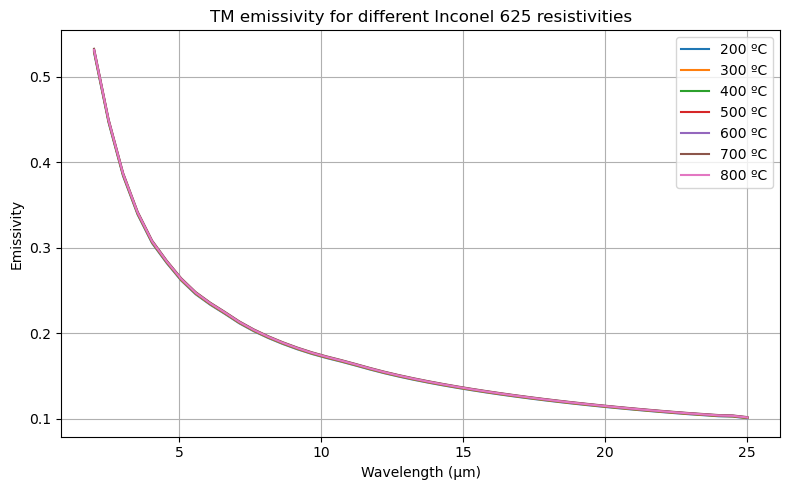

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for temp in temperatures:
    df_temp = df_results[df_results["temperature_C"] == temp]
    plt.plot(
        df_temp["wavelength_um"],
        df_temp["A_TM"],
        label=f"{temp} ºC"
    )

plt.xlabel("Wavelength (µm)")
plt.ylabel("Emissivity")
plt.title("TM emissivity for different Inconel 625 resistivities")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Nocoating y2

Convergence analysis

In [20]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================================================
# Convergence analysis for nocoating_x1.csv
# Using only the smallest resistivity case
# ============================================================

# --- Load surface profile ---
surface_profile = pd.read_csv(
    "csv/Inconel_gratings/nocoating_y2.csv",
    sep=r"\s+"
)

surface_profile["x"] = (
    surface_profile["x"]
    .str.replace(",", ".", regex=False)
    .astype(float) * 1e3
)

surface_profile["y"] = (
    surface_profile["y"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# --- Resistivity values ---
temperatures = np.arange(200, 801, 100)

resistivities = np.array([1.285, 1.296, 1.306, 1.315, 1.324, 1.333, 1.318])
resistivities = resistivities * 1e-4

# Use only the smallest resistivity
idx_min_rho = np.argmin(resistivities)
rho_selected = resistivities[idx_min_rho]
temp_selected = temperatures[idx_min_rho]

print(f"Selected temperature: {temp_selected} ºC")
print(f"Selected resistivity: {rho_selected:.4e}")

# ============================================================
# Convergence grid
# ============================================================

Num_ord_values = [60, 80, 100, 120, 140, 160]
slices_values = [20, 40, 60, 80, 100]

convergence_results = []

# Optional: use all wavelengths
wavelength_conv = wavelength

# If it is too slow, use a reduced wavelength grid:
# wavelength_conv = wavelength[::5]

# ============================================================
# Run convergence analysis
# ============================================================

for slices_conv in slices_values:
    for Num_ord_conv in Num_ord_values:
        if Num_ord_conv <= slices_conv:
                    continue
        R_TM = []
        T_TM = []
        A_TM = []
        N = slices_conv - 1
        for wv in tqdm(
            wavelength_conv,
            desc=f"slices={slices_conv}, Num_ord={Num_ord_conv}"
        ):

            # Complex permittivity for selected resistivity
            refractive_index = InconelPerm2(
                wv,
                resistivities,
                idx_min_rho
            )

            # Material arrays
            e_m = np.full(N, refractive_index)
            e_d = np.full(N, 1.0)
            e = [1, refractive_index]

            # Staircase discretization
            f_left_end, f_right_end, d, periods, permittivity_matrix = (
                Utils.discretize_rugosity_square_staricase(
                    surface_profile.copy(),
                    e_m=refractive_index,
                    e_d=1.0,
                    slices=slices_conv
                )
            )

            # RCWA calculation
            R_wv, T_wv = TM_solver.TransRefl(
                N=N,
                e_m=e_m,
                e_d=e_d,
                f1=f_left_end,
                f2=f_right_end,
                period=periods,
                d=d,
                e=e,
                wavelength=wv,
                theta=theta,
                Num_ord=Num_ord_conv,
                permittivity_matrix=None
            )

            A_wv = 1 - (R_wv + T_wv)

            R_TM.append(R_wv)
            T_TM.append(T_wv)
            A_TM.append(A_wv)

        convergence_results.append({
            "slices": slices_conv,
            "Num_ord": Num_ord_conv,
            "temperature_C": temp_selected,
            "resistivity": rho_selected,
            "wavelength_um": np.array(wavelength_conv),
            "R_TM": np.array(R_TM),
            "T_TM": np.array(T_TM),
            "A_TM": np.array(A_TM)
        })


# ============================================================
# Convert results into a long-format DataFrame
# ============================================================

rows = []

for result in convergence_results:
    for i, wv in enumerate(result["wavelength_um"]):
        rows.append({
            "slices": result["slices"],
            "Num_ord": result["Num_ord"],
            "temperature_C": result["temperature_C"],
            "resistivity": result["resistivity"],
            "wavelength_um": wv,
            "R_TM": result["R_TM"][i],
            "T_TM": result["T_TM"][i],
            "A_TM": result["A_TM"][i],
        })

df_conv = pd.DataFrame(rows)

df_conv.to_csv(
    "RCWA_convergence_nocoating_y2_min_resistivity.csv",
    index=False
)

df_conv.head()

Selected temperature: 200 ºC
Selected resistivity: 1.2850e-04


slices=100, Num_ord=160: 100%|█████████████████████████████████████████████████████████| 46/46 [15:52<00:00, 20.71s/it]


,slices,Num_ord,temperature_C,resistivity,wavelength_um,R_TM,T_TM,A_TM
0,20,60,200,0.000129,2.000000,0.328955,0.003990,0.667055
1,20,60,200,0.000129,2.511111,0.391255,0.003376,0.605368
2,20,60,200,0.000129,3.022222,0.443696,0.003156,0.553149
3,20,60,200,0.000129,3.533333,0.496977,0.003138,0.499885
4,20,60,200,0.000129,4.044444,0.547518,0.003307,0.449175


Main calculations

In [10]:
import numpy as np
import pandas as pd
from tqdm import tqdm

surface_profile = pd.read_csv("csv/Inconel_gratings/nocoating_y2.csv", sep = r"\s+")

surface_profile["x"] = surface_profile["x"].str.replace(",", ".", regex=False).astype(float) * 1e3
surface_profile["y"] = surface_profile["y"].str.replace(",", ".", regex=False).astype(float)

# Resistividades correspondientes a T = 200, 300, ..., 800 ºC
temperatures = np.arange(200, 801, 100)

resistivities = np.array([1.285, 1.296, 1.306, 1.315, 1.324, 1.333, 1.318])
resistivities = resistivities * 1e-4   


results = []

for idx, temp in enumerate(temperatures):

    R_TM = []
    T_TM = []
    A_TM = []

    for wv in tqdm(wavelength, desc=f"Temperature {temp} ºC"):

        # Complex permittivity for this wavelength and temperature
        refractive_index = InconelPerm2(wv, resistivities, idx)

        # Assign metal and dielectric permittivity to all layers
        e_m = np.full(N, refractive_index)
        e_d = np.full(N, 1.0)
        e = [1, refractive_index]

        # Discretize the arbitrary surface profile into staircase layers
        f_left_end, f_right_end, d, periods, permittivity_matrix = Utils.discretize_rugosity_square_staricase(
            surface_profile,
            e_m=refractive_index,
            e_d=1.0,
            slices=slices
        )

        # Compute reflection and transmission using RCWA
        R_wv, T_wv = TM_solver.TransRefl(
            N=N,
            e_m=e_m,
            e_d=e_d,
            f1=f_left_end,
            f2=f_right_end,
            period=periods,
            d=d,
            e=e,
            wavelength=wv,
            theta=theta,
            Num_ord=Num_ord,
            permittivity_matrix=None
        )

        # Absorptance / emissivity
        A_wv = 1 - (R_wv + T_wv)

        R_TM.append(R_wv)
        T_TM.append(T_wv)
        A_TM.append(A_wv)

        results.append({
            "temperature_C": temp,
            "resistivity": resistivities[idx],
            "wavelength_um": wv,
            "epsilon_real": np.real(refractive_index),
            "epsilon_imag": np.imag(refractive_index),
            "R_TM": R_wv,
            "T_TM": T_wv,
            "A_TM": A_wv
        })


# Convert to DataFrame
df_results = pd.DataFrame(results)

# Save CSV
df_results.to_csv("RCWA_Inconel_HagenRubens_temperaturesy2.csv", index=False)

df_results.head()

Temperature 800 ºC: 100%|██████████████████████████████████████████████████████████████| 46/46 [06:57<00:00,  9.08s/it]


,temperature_C,resistivity,wavelength_um,epsilon_real,epsilon_imag,R_TM,T_TM,A_TM
0,200,0.000129,2.000000,0.0,93.385214,0.457765,0.002383,0.539852
1,200,0.000129,2.511111,0.0,117.250324,0.539410,0.002252,0.458338
2,200,0.000129,3.022222,0.0,141.115435,0.596152,0.002044,0.401805
3,200,0.000129,3.533333,0.0,164.980545,0.640066,0.001902,0.358032
4,200,0.000129,4.044444,0.0,188.845655,0.674271,0.001691,0.324038


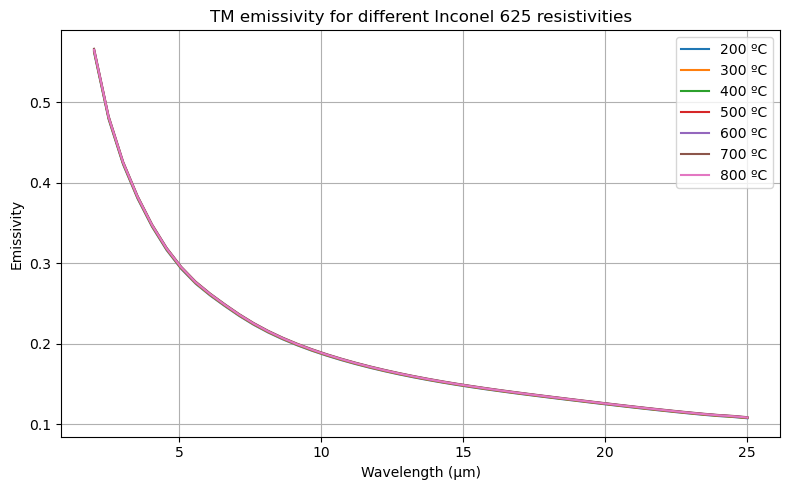

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for temp in temperatures:
    df_temp = df_results[df_results["temperature_C"] == temp]
    plt.plot(
        df_temp["wavelength_um"],
        df_temp["A_TM"],
        label=f"{temp} ºC"
    )

plt.xlabel("Wavelength (µm)")
plt.ylabel("Emissivity")
plt.title("TM emissivity for different Inconel 625 resistivities")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# convergence check

['slices', 'Num_ord', 'temperature_C', 'resistivity', 'wavelength_um', 'R_TM', 'T_TM', 'A_TM', 'grating']
24 combinaciones (Num_ord, slices) x 4 gratings
Ninguna combinacion evaluable baja de stability_err < 0.001
Combinaciones mas estables disponibles:
 Num_ord  slices  cost  stability_err  n_more_expensive
     160      80 12800       0.023721                 2
     140     100 14000       0.024059                 1
     140      80 11200       0.026366                 4
     140      60  8400       0.028492                 7
     160      60  9600       0.042252                 5
     120     100 12000       0.043363                 3
     120      80  9600       0.045067                 5
     120      60  7200       0.047005                 9
     120      40  4800       0.054600                13
     140      40  5600       0.060556                12


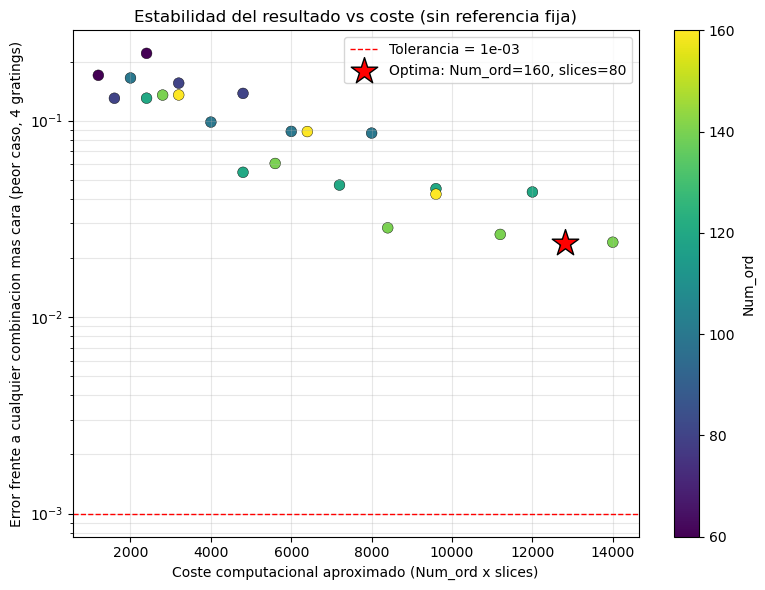


Peor comparacion (combo elegido vs combo mas caro) por grating:
nocoating_x1: err_max=2.37e-02 frente a Num_ord=140, slices=100
nocoating_x2: err_max=1.82e-02 frente a Num_ord=140, slices=100
nocoating_y1: err_max=1.66e-02 frente a Num_ord=140, slices=100
nocoating_y2: err_max=1.09e-02 frente a Num_ord=140, slices=100


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# ---------------------------------------------------------------------
# 1. Cargar los 4 CSV
# ---------------------------------------------------------------------
csv_files = {
    "nocoating_x1": "RCWA_convergence_nocoating_x1_min_resistivity.csv",
    "nocoating_x2": "RCWA_convergence_nocoating_x2_min_resistivity.csv",
    "nocoating_y1": "RCWA_convergence_nocoating_y1_min_resistivity.csv",
    "nocoating_y2": "RCWA_convergence_nocoating_y2_min_resistivity.csv",
}

dfs = []
for name, path in csv_files.items():
    df = pd.read_csv(path)
    df["grating"] = name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(df_all.columns.tolist())

# ---------------------------------------------------------------------
# 2. Indexar el espectro A_TM(wavelength) de cada combinacion, por grating
# ---------------------------------------------------------------------
spectra = {}  # (grating, Num_ord, slices) -> pd.Series indexada por wavelength_um

for (grating_name, num_ord, slices), df_case in df_all.groupby(["grating", "Num_ord", "slices"]):
    spectra[(grating_name, num_ord, slices)] = (
        df_case.sort_values("wavelength_um").set_index("wavelength_um")["A_TM"]
    )

gratings = df_all["grating"].unique()
combos = sorted(df_all[["Num_ord", "slices"]].drop_duplicates().itertuples(index=False, name=None))
print(f"{len(combos)} combinaciones (Num_ord, slices) x {len(gratings)} gratings")

# ---------------------------------------------------------------------
# 3. Error par-a-par entre TODAS las combinaciones (sin fijar referencia)
#    Para cada grating, se calcula la matriz de error err_max(combo_a, combo_b)
# ---------------------------------------------------------------------
def combo_cost(combo):
    num_ord, slices = combo
    return num_ord * slices

pairwise_errors = {g: {} for g in gratings}

for grating_name in gratings:
    for combo_a, combo_b in combinations(combos, 2):
        key_a = (grating_name, *combo_a)
        key_b = (grating_name, *combo_b)
        if key_a not in spectra or key_b not in spectra:
            continue
        s_a, s_b = spectra[key_a].align(spectra[key_b], join="inner")
        err_max = np.max(np.abs(s_a.values - s_b.values))
        pairwise_errors[grating_name][(combo_a, combo_b)] = err_max
        pairwise_errors[grating_name][(combo_b, combo_a)] = err_max

# ---------------------------------------------------------------------
# 4. Para cada combinacion candidata, medir cuanto cambia el resultado
#    frente a CUALQUIER combinacion mas cara (mayor coste) del grid.
#    Si ese cambio maximo es pequeno, significa que ya se ha "convergido"
#    y no hace falta pagar el coste de ir a una combinacion mayor.
# ---------------------------------------------------------------------
stability_records = []

for combo in combos:
    more_expensive = [c for c in combos if combo_cost(c) > combo_cost(combo)]

    worst_case_over_gratings = 0.0
    for grating_name in gratings:
        for other in more_expensive:
            err = pairwise_errors[grating_name].get((combo, other))
            if err is not None:
                worst_case_over_gratings = max(worst_case_over_gratings, err)

    stability_records.append(
        {
            "Num_ord": combo[0],
            "slices": combo[1],
            "cost": combo_cost(combo),
            "stability_err": worst_case_over_gratings,
            "n_more_expensive": len(more_expensive),
        }
    )

df_stability = pd.DataFrame(stability_records).sort_values("cost")

# La combinacion mas cara del grid no tiene nada mas caro con que compararse
# (n_more_expensive == 0): su stability_err es 0 por definicion, pero eso NO
# significa que sea barata ni fiable, simplemente no se puede evaluar. La
# excluimos de la busqueda de "mas barata que cumple tolerancia".
df_stability_evaluable = df_stability[df_stability["n_more_expensive"] > 0]

# ---------------------------------------------------------------------
# 5. Elegir la combinacion mas barata cuyo resultado ya no cambia
#    significativamente frente a ninguna combinacion mas cara
# ---------------------------------------------------------------------
tolerance = 1e-3  # ajustar segun la precision que necesites

df_ok = df_stability_evaluable[df_stability_evaluable["stability_err"] < tolerance].sort_values("cost")

if df_ok.empty:
    print(f"Ninguna combinacion evaluable baja de stability_err < {tolerance}")
    print("Combinaciones mas estables disponibles:")
    print(df_stability_evaluable.sort_values("stability_err").head(10).to_string(index=False))
    best = df_stability_evaluable.sort_values("stability_err").iloc[0]
else:
    best = df_ok.iloc[0]
    print("=== Combinacion mas barata cuyo resultado ya no cambia frente a combinaciones mas caras ===")
    print(
        f"Num_ord = {int(best['Num_ord'])}, slices = {int(best['slices'])}, "
        f"stability_err = {best['stability_err']:.2e}, cost = {int(best['cost'])}"
    )
    print("\nTop 10 candidatas (ordenadas por coste):")
    print(df_ok.head(10).to_string(index=False))

# ---------------------------------------------------------------------
# 6. Grafica coste vs error de estabilidad
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 6))
sc = plt.scatter(
    df_stability_evaluable["cost"],
    df_stability_evaluable["stability_err"],
    c=df_stability_evaluable["Num_ord"],
    cmap="viridis",
    s=60,
    edgecolor="k",
    linewidth=0.3,
)
plt.colorbar(sc, label="Num_ord")
plt.axhline(tolerance, color="red", linestyle="--", linewidth=1, label=f"Tolerancia = {tolerance:.0e}")

plt.scatter(
    best["cost"],
    best["stability_err"],
    marker="*",
    s=400,
    color="red",
    edgecolor="black",
    zorder=5,
    label=f"Optima: Num_ord={int(best['Num_ord'])}, slices={int(best['slices'])}",
)

plt.xlabel("Coste computacional aproximado (Num_ord x slices)")
plt.ylabel("Error frente a cualquier combinacion mas cara (peor caso, 4 gratings)")
plt.yscale("log")
plt.title("Estabilidad del resultado vs coste (sin referencia fija)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 7. Detalle por grating para la combinacion elegida: contra que
#    combinacion mas cara tiene el mayor desacuerdo (diagnostico)
# ---------------------------------------------------------------------
print("\nPeor comparacion (combo elegido vs combo mas caro) por grating:")
chosen = (int(best["Num_ord"]), int(best["slices"]))
more_expensive = [c for c in combos if combo_cost(c) > combo_cost(chosen)]

for grating_name in gratings:
    worst_err, worst_other = 0.0, None
    for other in more_expensive:
        err = pairwise_errors[grating_name].get((chosen, other))
        if err is not None and err > worst_err:
            worst_err, worst_other = err, other
    print(f"{grating_name}: err_max={worst_err:.2e} frente a Num_ord={worst_other[0]}, slices={worst_other[1]}")


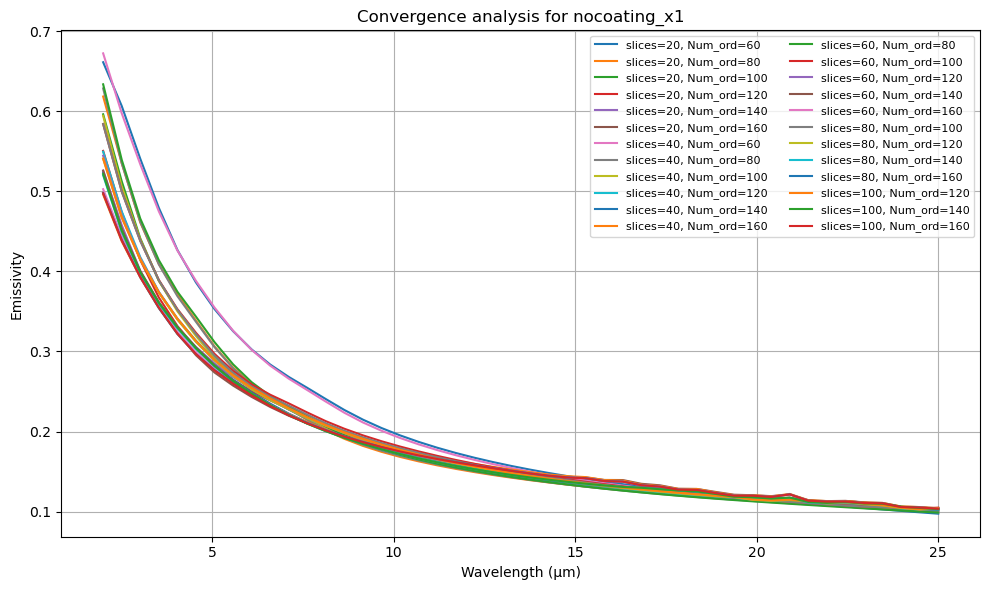

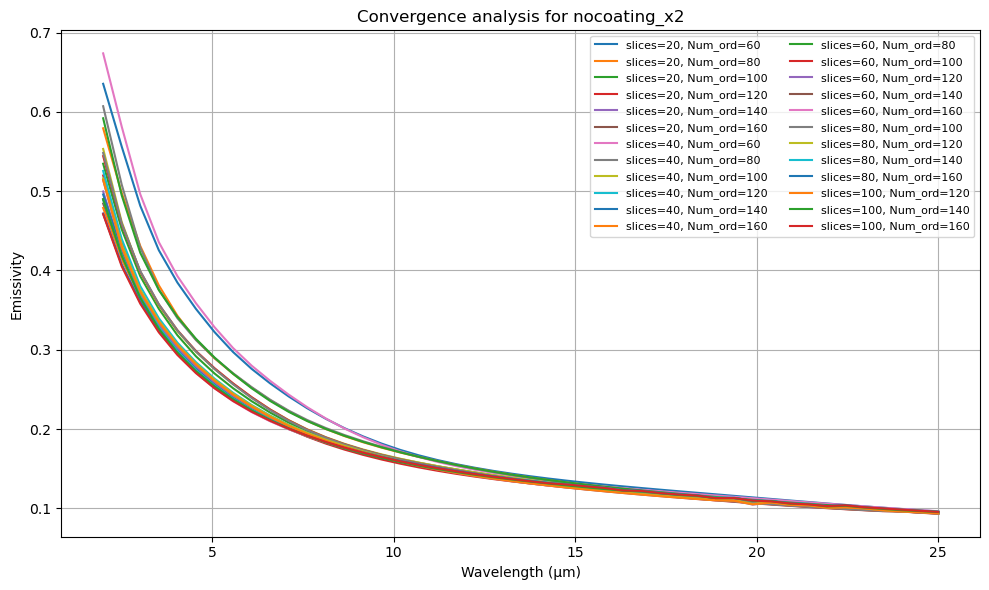

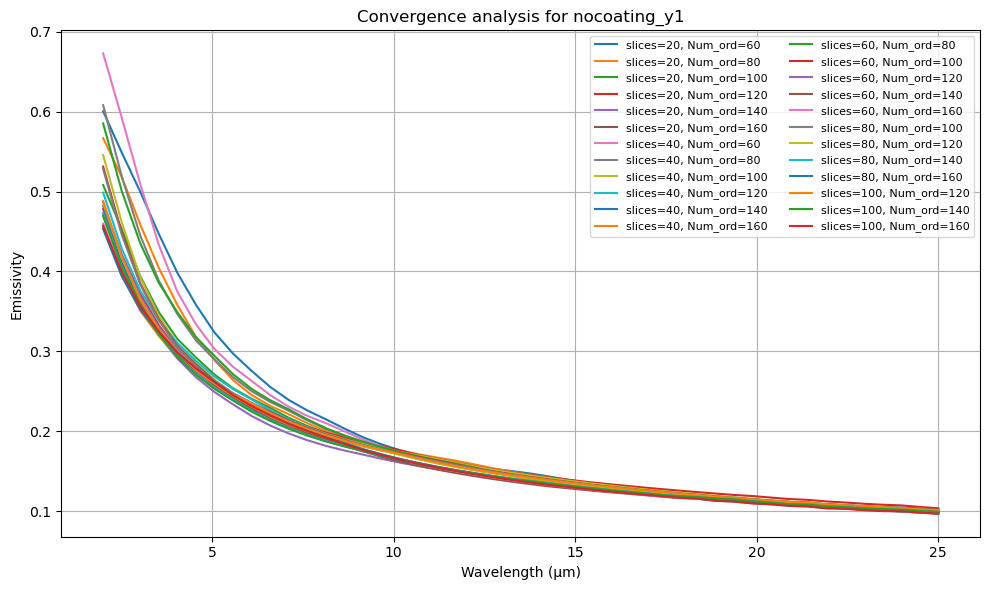

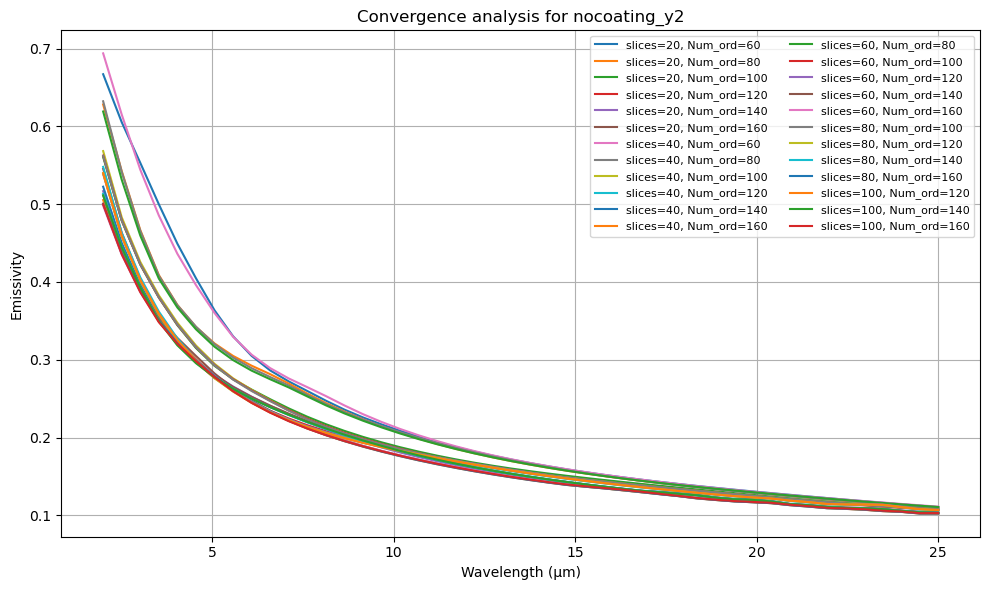

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Plot convergence results for the 4 gratings
# ============================================================

csv_files = {
    "nocoating_x1": "RCWA_convergence_nocoating_x1_min_resistivity.csv",
    "nocoating_x2": "RCWA_convergence_nocoating_x2_min_resistivity.csv",
    "nocoating_y1": "RCWA_convergence_nocoating_y1_min_resistivity.csv",
    "nocoating_y2": "RCWA_convergence_nocoating_y2_min_resistivity.csv",
}

for grating_name, csv_path in csv_files.items():

    df = pd.read_csv(csv_path)

    plt.figure(figsize=(10, 6))

    for (slices_conv, Num_ord_conv), df_case in df.groupby(["slices", "Num_ord"]):

        df_case = df_case.sort_values("wavelength_um")

        plt.plot(
            df_case["wavelength_um"],
            df_case["A_TM"],
            label=f"slices={slices_conv}, Num_ord={Num_ord_conv}"
        )

    plt.xlabel("Wavelength (µm)")
    plt.ylabel("Emissivity")
    plt.title(f"Convergence analysis for {grating_name}")
    plt.grid(True)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

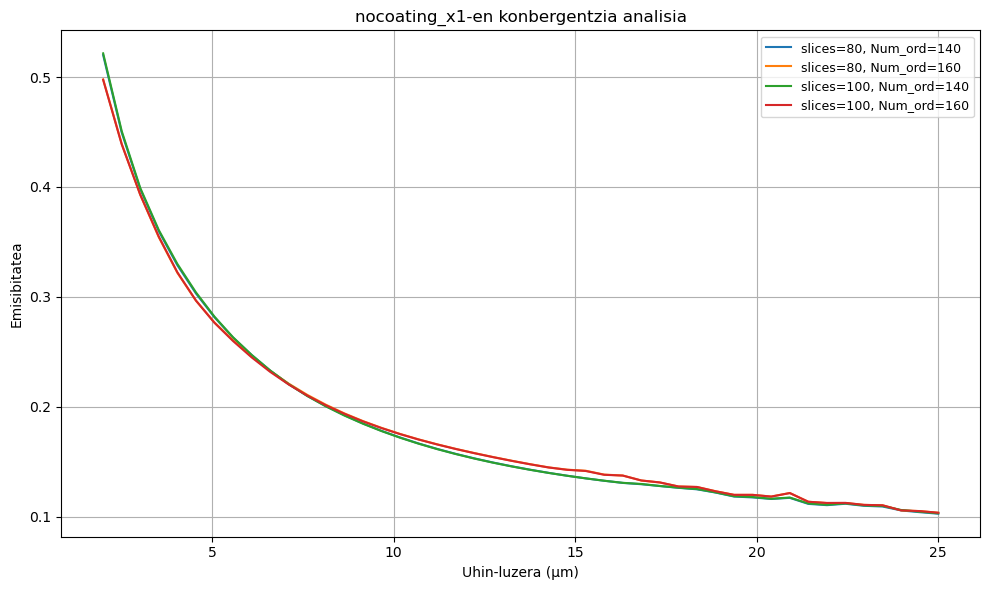

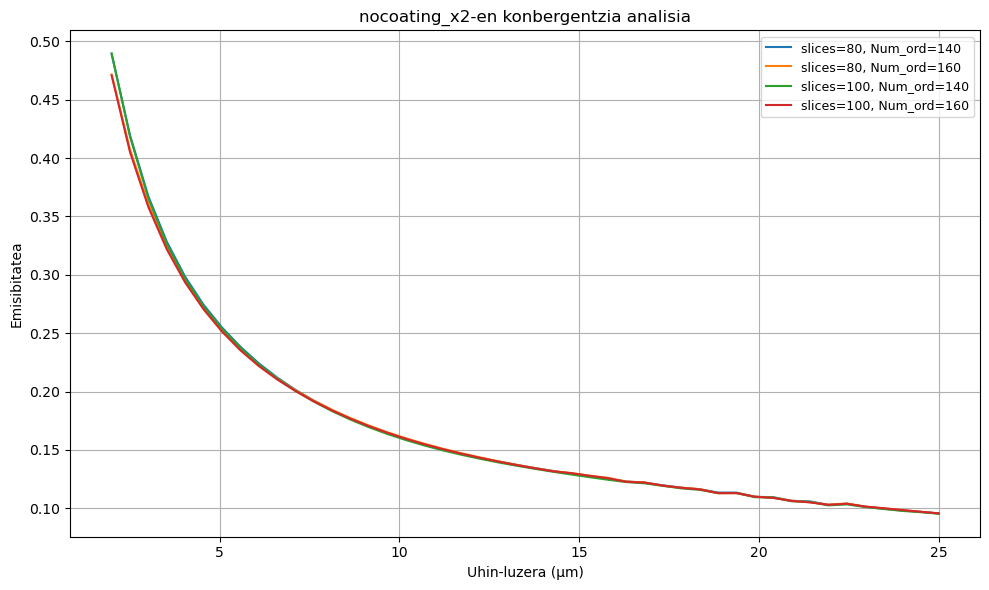

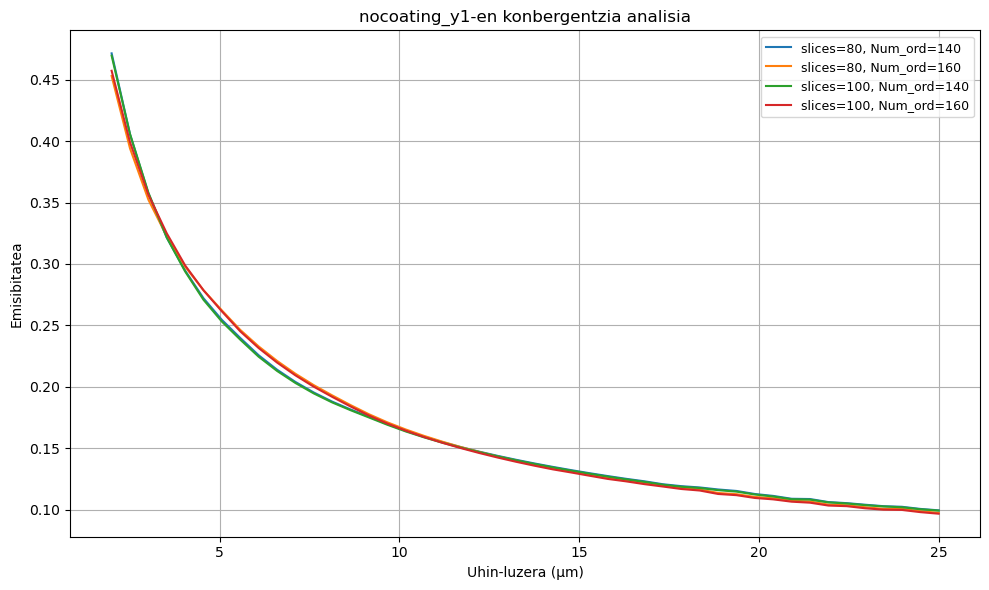

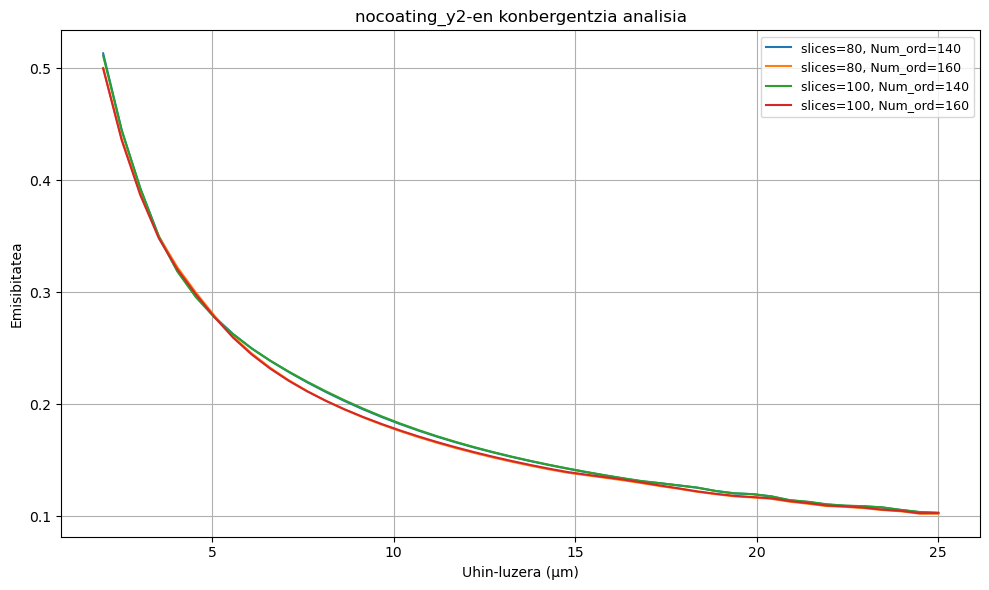

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Plot convergence results for selected cases only
# slices = 60, 80
# Num_ord = 100, 120
# ============================================================

csv_files = {
    "nocoating_x1": "RCWA_convergence_nocoating_x1_min_resistivity.csv",
    "nocoating_x2": "RCWA_convergence_nocoating_x2_min_resistivity.csv",
    "nocoating_y1": "RCWA_convergence_nocoating_y1_min_resistivity.csv",
    "nocoating_y2": "RCWA_convergence_nocoating_y2_min_resistivity.csv",
}

selected_slices = [80, 100]
selected_Num_ord = [140, 160]

for grating_name, csv_path in csv_files.items():

    df = pd.read_csv(csv_path)

    df_filtered = df[
        (df["slices"].isin(selected_slices)) &
        (df["Num_ord"].isin(selected_Num_ord))
    ]

    plt.figure(figsize=(10, 6))

    for (slices_conv, Num_ord_conv), df_case in df_filtered.groupby(["slices", "Num_ord"]):

        df_case = df_case.sort_values("wavelength_um")

        plt.plot(
            df_case["wavelength_um"],
            df_case["A_TM"],
            label=f"slices={slices_conv}, Num_ord={Num_ord_conv}"
        )

    plt.xlabel("Uhin-luzera (µm)")
    plt.ylabel("Emisibitatea")
    plt.title(f"{grating_name}-en konbergentzia analisia")
    plt.grid(True)
    plt.legend(fontsize=9)
    plt.tight_layout()

    # Save as PNG
    plt.savefig(f"{grating_name}_convergence_selected.png", dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1. Plot de tus simulaciones RCWA
# ==========================


df_results = pd.read_csv("RCWA_Inconel_HagenRubens_temperaturesx1.csv")
plt.figure(figsize=(9, 5))

for temp in temperatures:
    df_temp = df_results[df_results["temperature_C"] == temp].sort_values("wavelength_um")
    
    plt.plot(
        df_temp["wavelength_um"],
        df_temp["A_TM"],
        label=f"RCWA {temp} ºC",
        linewidth=1.6
    )


# ==========================
# 2. Cargar CSV externo
# ==========================

df_csv = pd.read_csv("csv/results/1_inconel_temps_corregida_cortada.csv")

# Renombrar primera columna como Lambda
df_csv.rename(columns={df_csv.columns[0]: "Lambda"}, inplace=True)

# Limpiar nombres de columnas
df_csv.columns = df_csv.columns.astype(str).str.strip()

print("Columnas del CSV:")
print(df_csv.columns)


# ==========================
# 3. Plotear todas las temperaturas del CSV externo
# ==========================

for temp in temperatures:

    # Buscar columna que contenga la temperatura
    matching_cols = [c for c in df_csv.columns if str(temp) in c]

    if len(matching_cols) == 0:
        print(f"No se encontró columna para {temp} ºC")
        continue

    # Elegir la primera coincidencia
    col_temp = matching_cols[0]

    plt.plot(
        df_csv["Lambda"],
        df_csv[col_temp],
        linewidth=2.2,
        linestyle="--",
        label=f"Results {temp} ºC"
    )


# ==========================
# 4. Formato
# ==========================

plt.xlabel("Wavelength (µm)")
plt.ylabel("Emissivity / Absorptance")
plt.title("TM emissivity comparison")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
temperatures = np.arange(200, 801, 100)

resistivities = np.array([1.285, 1.296, 1.306, 1.315, 1.324, 1.333, 1.318])


resistivities = resistivities * 1e-4 

Columnas del CSV:
Index(['Lambda', '200 ºC', '300 ºC', '400 ºC', '500 ºC', '600 ºC', '700 ºC',
       '800 ºC'],
      dtype='object')


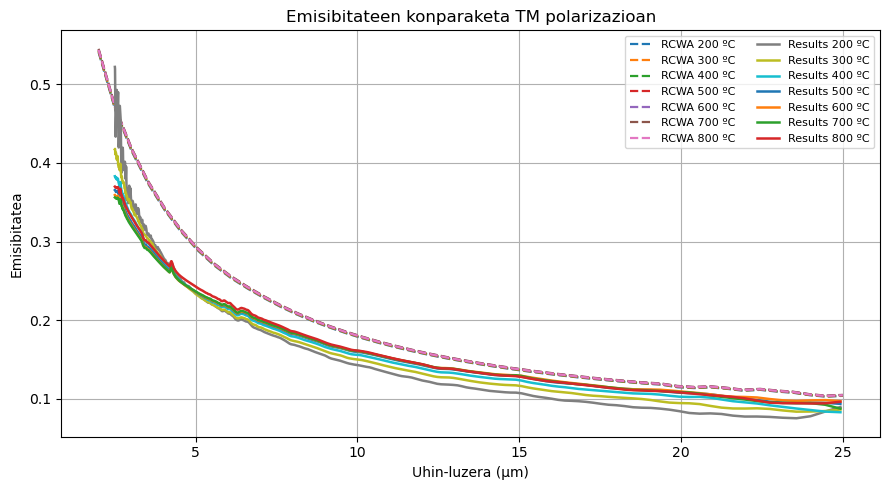

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1. Cargar resultados RCWA
# ==========================

df_results = pd.read_csv("RCWA_Inconel_HagenRubens_temperaturesx1.csv")

plt.figure(figsize=(9, 5))

# ==========================
# 2. Plotear simulaciones RCWA en línea discontinua
# ==========================

for temp in temperatures:
    df_temp = df_results[df_results["temperature_C"] == temp].sort_values("wavelength_um")
    
    plt.plot(
        df_temp["wavelength_um"],
        df_temp["A_TM"],
        label=f"RCWA {temp} ºC",
        linewidth=1.6,
        linestyle="--"
    )


# ==========================
# 3. Cargar CSV externo con resultados reales
# ==========================

df_csv = pd.read_csv("csv/results/1_inconel_temps_corregida_cortada.csv")

# Renombrar primera columna como Lambda
df_csv.rename(columns={df_csv.columns[0]: "Lambda"}, inplace=True)

# Limpiar nombres de columnas
df_csv.columns = df_csv.columns.astype(str).str.strip()

print("Columnas del CSV:")
print(df_csv.columns)


# ==========================
# 4. Plotear resultados reales en línea continua
# ==========================

for temp in temperatures:

    matching_cols = [c for c in df_csv.columns if str(temp) in c]

    if len(matching_cols) == 0:
        print(f"No se encontró columna para {temp} ºC")
        continue

    col_temp = matching_cols[0]

    plt.plot(
        df_csv["Lambda"],
        df_csv[col_temp],
        linewidth=1.8,
        linestyle="-",
        label=f"Results {temp} ºC"
    )


# ==========================
# 5. Formato
# ==========================

plt.xlabel("Uhin-luzera (µm)")
plt.ylabel("Emisibitatea")
plt.title("Emisibitateen konparaketa TM polarizazioan")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.tight_layout()

# Guardar figura
plt.savefig("TM_emissivity_comparison_x1.png", dpi=300, bbox_inches="tight")

plt.show()

Columnas del CSV:
Index(['Lambda', '200 ºC', '300 ºC', '400 ºC', '500 ºC', '600 ºC', '700 ºC',
       '800 ºC'],
      dtype='object')


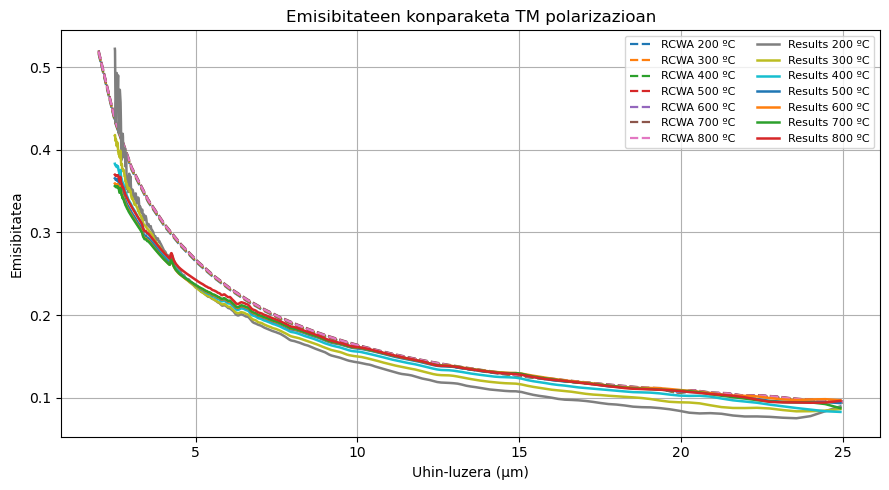

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1. Cargar resultados RCWA
# ==========================

df_results = pd.read_csv("RCWA_Inconel_HagenRubens_temperaturesx2.csv")

plt.figure(figsize=(9, 5))

# ==========================
# 2. Plotear simulaciones RCWA en línea discontinua
# ==========================

for temp in temperatures:
    df_temp = df_results[df_results["temperature_C"] == temp].sort_values("wavelength_um")
    
    plt.plot(
        df_temp["wavelength_um"],
        df_temp["A_TM"],
        label=f"RCWA {temp} ºC",
        linewidth=1.6,
        linestyle="--"
    )


# ==========================
# 3. Cargar CSV externo con resultados reales
# ==========================

df_csv = pd.read_csv("csv/results/1_inconel_temps_corregida_cortada.csv")

# Renombrar primera columna como Lambda
df_csv.rename(columns={df_csv.columns[0]: "Lambda"}, inplace=True)

# Limpiar nombres de columnas
df_csv.columns = df_csv.columns.astype(str).str.strip()

print("Columnas del CSV:")
print(df_csv.columns)


# ==========================
# 4. Plotear resultados reales en línea continua
# ==========================

for temp in temperatures:

    matching_cols = [c for c in df_csv.columns if str(temp) in c]

    if len(matching_cols) == 0:
        print(f"No se encontró columna para {temp} ºC")
        continue

    col_temp = matching_cols[0]

    plt.plot(
        df_csv["Lambda"],
        df_csv[col_temp],
        linewidth=1.8,
        linestyle="-",
        label=f"Results {temp} ºC"
    )


# ==========================
# 5. Formato
# ==========================

plt.xlabel("Uhin-luzera (µm)")
plt.ylabel("Emisibitatea")
plt.title("Emisibitateen konparaketa TM polarizazioan")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.tight_layout()

# Guardar figura
plt.savefig("TM_emissivity_comparison_x2.png", dpi=300, bbox_inches="tight")

plt.show()

Columnas del CSV:
Index(['Lambda', '200 ºC', '300 ºC', '400 ºC', '500 ºC', '600 ºC', '700 ºC',
       '800 ºC'],
      dtype='object')


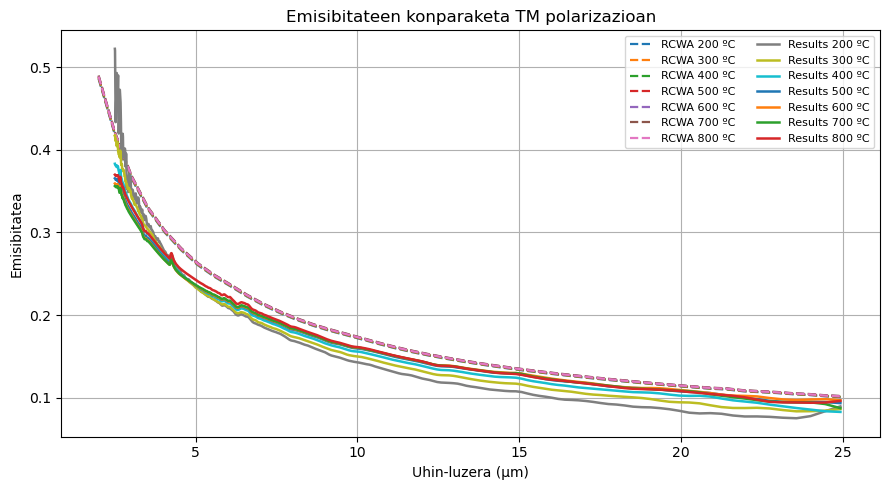

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1. Cargar resultados RCWA
# ==========================

df_results = pd.read_csv("RCWA_Inconel_HagenRubens_temperaturesy1.csv")

plt.figure(figsize=(9, 5))

# ==========================
# 2. Plotear simulaciones RCWA en línea discontinua
# ==========================

for temp in temperatures:
    df_temp = df_results[df_results["temperature_C"] == temp].sort_values("wavelength_um")
    
    plt.plot(
        df_temp["wavelength_um"],
        df_temp["A_TM"],
        label=f"RCWA {temp} ºC",
        linewidth=1.6,
        linestyle="--"
    )


# ==========================
# 3. Cargar CSV externo con resultados reales
# ==========================

df_csv = pd.read_csv("csv/results/1_inconel_temps_corregida_cortada.csv")

# Renombrar primera columna como Lambda
df_csv.rename(columns={df_csv.columns[0]: "Lambda"}, inplace=True)

# Limpiar nombres de columnas
df_csv.columns = df_csv.columns.astype(str).str.strip()

print("Columnas del CSV:")
print(df_csv.columns)


# ==========================
# 4. Plotear resultados reales en línea continua
# ==========================

for temp in temperatures:

    matching_cols = [c for c in df_csv.columns if str(temp) in c]

    if len(matching_cols) == 0:
        print(f"No se encontró columna para {temp} ºC")
        continue

    col_temp = matching_cols[0]

    plt.plot(
        df_csv["Lambda"],
        df_csv[col_temp],
        linewidth=1.8,
        linestyle="-",
        label=f"Results {temp} ºC"
    )


# ==========================
# 5. Formato
# ==========================

plt.xlabel("Uhin-luzera (µm)")
plt.ylabel("Emisibitatea")
plt.title("Emisibitateen konparaketa TM polarizazioan")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.tight_layout()

# Guardar figura
plt.savefig("TM_emissivity_comparison_y1.png", dpi=300, bbox_inches="tight")

plt.show()

Columnas del CSV:
Index(['Lambda', '200 ºC', '300 ºC', '400 ºC', '500 ºC', '600 ºC', '700 ºC',
       '800 ºC'],
      dtype='object')


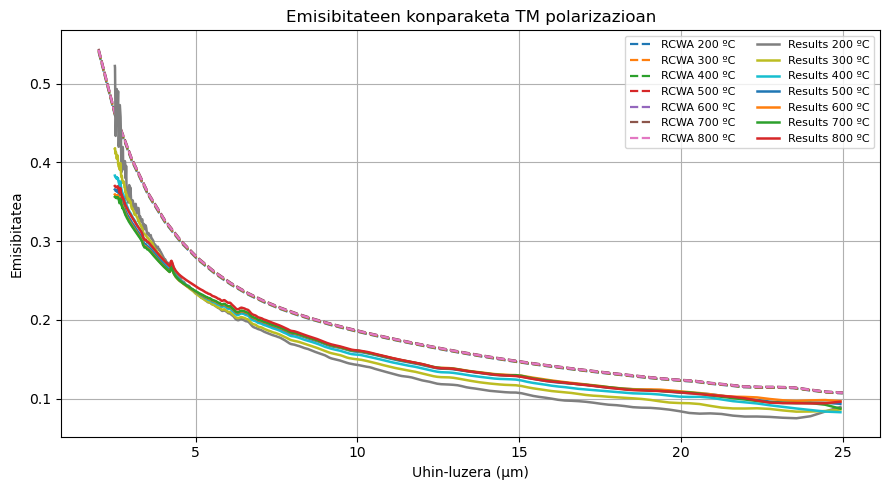

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1. Cargar resultados RCWA
# ==========================

df_results = pd.read_csv("RCWA_Inconel_HagenRubens_temperaturesy2.csv")

plt.figure(figsize=(9, 5))

# ==========================
# 2. Plotear simulaciones RCWA en línea discontinua
# ==========================

for temp in temperatures:
    df_temp = df_results[df_results["temperature_C"] == temp].sort_values("wavelength_um")
    
    plt.plot(
        df_temp["wavelength_um"],
        df_temp["A_TM"],
        label=f"RCWA {temp} ºC",
        linewidth=1.6,
        linestyle="--"
    )


# ==========================
# 3. Cargar CSV externo con resultados reales
# ==========================

df_csv = pd.read_csv("csv/results/1_inconel_temps_corregida_cortada.csv")

# Renombrar primera columna como Lambda
df_csv.rename(columns={df_csv.columns[0]: "Lambda"}, inplace=True)

# Limpiar nombres de columnas
df_csv.columns = df_csv.columns.astype(str).str.strip()

print("Columnas del CSV:")
print(df_csv.columns)


# ==========================
# 4. Plotear resultados reales en línea continua
# ==========================

for temp in temperatures:

    matching_cols = [c for c in df_csv.columns if str(temp) in c]

    if len(matching_cols) == 0:
        print(f"No se encontró columna para {temp} ºC")
        continue

    col_temp = matching_cols[0]

    plt.plot(
        df_csv["Lambda"],
        df_csv[col_temp],
        linewidth=1.8,
        linestyle="-",
        label=f"Results {temp} ºC"
    )


# ==========================
# 5. Formato
# ==========================

plt.xlabel("Uhin-luzera (µm)")
plt.ylabel("Emisibitatea")
plt.title("Emisibitateen konparaketa TM polarizazioan")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.tight_layout()

# Guardar figura
plt.savefig("TM_emissivity_comparison_y2.png", dpi=300, bbox_inches="tight")

plt.show()

   temperature_C  resistivity  wavelength_um  epsilon_real  epsilon_imag  \
0            200     0.000129       2.000000           0.0     93.385214   
1            200     0.000129       2.511111           0.0    117.250324   
2            200     0.000129       3.022222           0.0    141.115435   
3            200     0.000129       3.533333           0.0    164.980545   
4            200     0.000129       4.044444           0.0    188.845655   

       R_TM      T_TM      A_TM profile  
0  0.456957  0.002277  0.540767      x1  
1  0.530090  0.002018  0.467891      x1  
2  0.583282  0.001850  0.414868      x1  
3  0.624869  0.001831  0.373300      x1  
4  0.658304  0.001888  0.339807      x1  
Index(['temperature_C', 'resistivity', 'wavelength_um', 'epsilon_real',
       'epsilon_imag', 'R_TM', 'T_TM', 'A_TM', 'profile'],
      dtype='object')
Columnas del CSV externo:
Index(['Lambda', '200 ºC', '300 ºC', '400 ºC', '500 ºC', '600 ºC', '700 ºC',
       '800 ºC'],
      dtype='obje

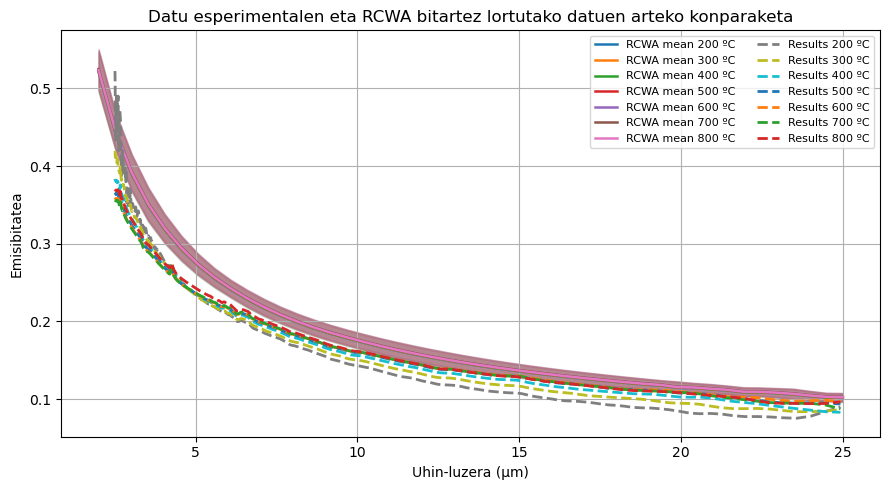

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# 1. Cargar los 4 resultados RCWA
# ==========================

profiles = ["x1", "x2", "y1", "y2"]

df_list = []

for profile in profiles:
    csv_path = f"RCWA_Inconel_HagenRubens_temperatures{profile}.csv"
    
    df = pd.read_csv(csv_path)
    df["profile"] = profile
    
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)

print(df_all.head())
print(df_all.columns)


# ==========================
# 2. Calcular media y desviación estándar
# ==========================

df_stats = (
    df_all
    .groupby(["temperature_C", "wavelength_um"], as_index=False)
    .agg(
        A_TM_mean=("A_TM", "mean"),
        A_TM_std=("A_TM", "std")
    )
)

# Por seguridad, ordenar
df_stats = df_stats.sort_values(["temperature_C", "wavelength_um"])


# ==========================
# 3. Plot RCWA medio ± desviación estándar
# ==========================

plt.figure(figsize=(9, 5))

for temp in temperatures:
    df_temp = df_stats[df_stats["temperature_C"] == temp].sort_values("wavelength_um")
    
    wavelength = df_temp["wavelength_um"].values
    mean = df_temp["A_TM_mean"].values
    std = df_temp["A_TM_std"].values
    
    line, = plt.plot(
        wavelength,
        mean,
        label=f"RCWA mean {temp} ºC",
        linewidth=1.8
    )
    
    plt.fill_between(
        wavelength,
        mean - std,
        mean + std,
        alpha=0.2,
        color=line.get_color()
    )


# ==========================
# 4. Cargar CSV externo
# ==========================

df_csv = pd.read_csv("csv/results/1_inconel_temps_corregida_cortada.csv")

# Renombrar primera columna como Lambda
df_csv.rename(columns={df_csv.columns[0]: "Lambda"}, inplace=True)

# Limpiar nombres de columnas
df_csv.columns = df_csv.columns.astype(str).str.strip()

print("Columnas del CSV externo:")
print(df_csv.columns)


# ==========================
# 5. Plotear todas las temperaturas del CSV externo
# ==========================

for temp in temperatures:

    matching_cols = [c for c in df_csv.columns if str(temp) in c]

    if len(matching_cols) == 0:
        print(f"No se encontró columna para {temp} ºC")
        continue

    col_temp = matching_cols[0]

    plt.plot(
        df_csv["Lambda"],
        df_csv[col_temp],
        linewidth=2.0,
        linestyle="--",
        label=f"Results {temp} ºC"
    )


# ==========================
# 6. Formato
# ==========================

plt.xlabel("Uhin-luzera (µm)")
plt.ylabel("Emisibitatea")
plt.title("Datu esperimentalen eta RCWA bitartez lortutako datuen arteko konparaketa")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.tight_layout()

plt.savefig("TM_emissivity_comparison_mean_std.png", dpi=300, bbox_inches="tight")

plt.show()